# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

Which variables would we need to **dummify**?

In [1]:
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset("penguins")

print(penguins.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


Let's use `bill_length_mm` to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Simple linear regression (e.g. straight-line) model
* Quadratic (degree 2 polynomial) model
* Cubic (degree 3 polynomial) model
* Degree 10 polynomial model

Make predictions for each model and plot your fitted models on the scatterplot.

In [2]:
penguins.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


* Are any of the models above underfitting the data? If so, which ones and how can you tell?
* Are any of thhe models above overfitting the data? If so, which ones and how can you tell?
* Which of the above models do you think fits the data best and why?

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Categorical columns: ['species', 'island', 'sex']


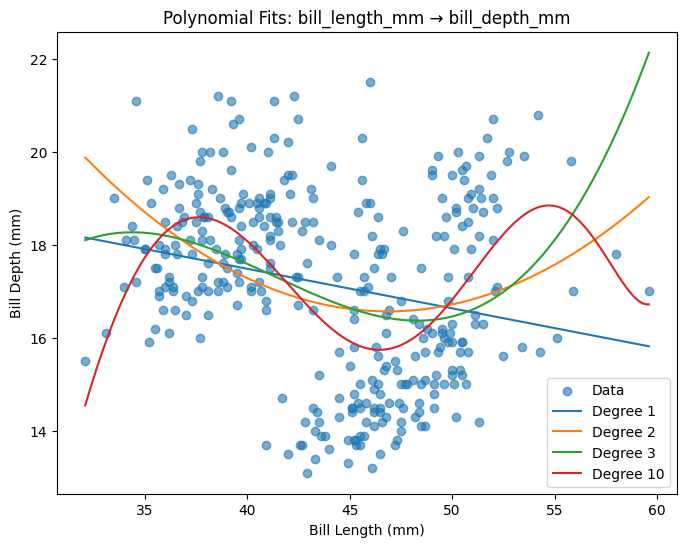

   Degree        R²
0       1  0.055250
1       2  0.113569
2       3  0.142488
3      10  0.275155


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

penguins = sns.load_dataset("penguins")
print(penguins.head())

print("\nCategorical columns:", penguins.select_dtypes(include=["object"]).columns.tolist())

penguins = penguins.dropna(subset=["bill_length_mm", "bill_depth_mm"])
X = penguins[["bill_length_mm"]].values
y = penguins["bill_depth_mm"].values

degrees = [1, 2, 3, 10]
x_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
r2_list = []

plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.6, label="Data")

for d in degrees:
    poly = PolynomialFeatures(d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_grid = model.predict(poly.transform(x_grid))
    plt.plot(x_grid, y_grid, label=f"Degree {d}")
    r2_list.append((d, r2_score(y, model.predict(X_poly))))

plt.title("Polynomial Fits: bill_length_mm → bill_depth_mm")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend()
plt.show()

r2_df = pd.DataFrame(r2_list, columns=["Degree", "R²"])
print(r2_df)


Underfitting:
The degree 1 (linear) model underfits because it’s too simple and doesn’t capture the curve in the data.

Overfitting:
The degree 10 model overfits since it’s really wiggly and tries to fit every point, including noise.

Best fit:
The degree 2 or 3 models fit best because they show the main pattern without being too simple or too complicate